In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
!pip install openpyxl

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
file_path = "Sales Data.xlsx"
excel_data = pd.ExcelFile(file_path)
print(excel_data.sheet_names)


['2022', '2023', '2024']


In [7]:
df_2022 = pd.read_excel(file_path, sheet_name="2022")
df_2023 = pd.read_excel(file_path, sheet_name="2023")
df_2024 = pd.read_excel(file_path, sheet_name="2024")

print("2022:", df_2022.shape)
print("2023:", df_2023.shape)
print("2024:", df_2024.shape)


2022: (915, 8)
2023: (906, 8)
2024: (917, 8)


In [8]:
# Combine Dataset

df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

print("Combined Data Shape:", df.shape)

Combined Data Shape: (2738, 8)


In [9]:
df.head()

,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type
0,2022-01-01,Almonds,West,37,295.16,Meena,Online,Retail
1,2022-01-01,Raisins,East,14,218.39,Raj,Online,Wholesale
2,2022-01-01,Walnuts,West,45,642.71,Anita,Online,Retail
3,2022-01-02,Pistachios,South,6,32.33,Raj,Offline,Retail
4,2022-01-02,Cashews,East,41,509.45,Meena,Online,Wholesale


In [10]:
print(df.columns.tolist())

['Date', 'Product', 'Region', 'Units_Sold', 'Revenue', 'Salesperson', 'Channel', 'Customer_Type']


In [11]:
#Dataset ki basic information

print("Rows and Columns:", df.shape)

Rows and Columns: (2738, 8)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2738 entries, 0 to 2737
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2738 non-null   object 
 1   Product        2738 non-null   object 
 2   Region         2738 non-null   object 
 3   Units_Sold     2738 non-null   int64  
 4   Revenue        2738 non-null   float64
 5   Salesperson    2738 non-null   object 
 6   Channel        2738 non-null   object 
 7   Customer_Type  2738 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 171.3+ KB


In [13]:
#Check Missing Values

df.isnull().sum()

Date             0
Product          0
Region           0
Units_Sold       0
Revenue          0
Salesperson      0
Channel          0
Customer_Type    0
dtype: int64

In [14]:
#Check Dublicates values

print("Duplicate rows:", df.duplicated().sum())



Duplicate rows: 0


In [15]:
df.describe()

,Units_Sold,Revenue
count,2738.000000,2738.000000
mean,25.292184,316.900661
std,14.517527,220.511950
min,1.000000,5.180000
25%,13.000000,138.652500
50%,25.000000,274.415000
75%,38.000000,450.852500
max,50.000000,997.960000


In [16]:
#Date convert in  datetime 

df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [17]:
# Add coloumn is year, month , month name

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

df.head()


,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type,Year,Month,Month_Name
0,2022-01-01,Almonds,West,37,295.16,Meena,Online,Retail,2022,1,January
1,2022-01-01,Raisins,East,14,218.39,Raj,Online,Wholesale,2022,1,January
2,2022-01-01,Walnuts,West,45,642.71,Anita,Online,Retail,2022,1,January
3,2022-01-02,Pistachios,South,6,32.33,Raj,Offline,Retail,2022,1,January
4,2022-01-02,Cashews,East,41,509.45,Meena,Online,Wholesale,2022,1,January


In [18]:
#Total Revenue

total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 867674.01


In [21]:
#Avg Revenue


average_revenue = df["Revenue"].mean()

print("Average Revenue per Transaction:", average_revenue)

Average Revenue per Transaction: 316.90066106647186


In [19]:
#Total Unit Sold

total_units = df["Units_Sold"].sum()

print("Total Units Sold:", total_units)

Total Units Sold: 69250


In [20]:
# No. Of Transactions

total_transactions = len(df)

print("Total Transactions:", total_transactions)

Total Transactions: 2738


In [22]:
#Revenue per Unit

revenue_per_unit = total_revenue / total_units

print("Revenue per Unit:", round(revenue_per_unit, 2))

Revenue per Unit: 12.53


In [23]:
#Year-wise Revenue

yearly_sales = df.groupby("Year")["Revenue"].sum()

print(yearly_sales)

Year
2022    293471.66
2023    288037.87
2024    286164.48
Name: Revenue, dtype: float64


In [24]:
#Year-wise Units Sold

yearly_units = df.groupby("Year")["Units_Sold"].sum()

print(yearly_units)

Year
2022    23373
2023    22986
2024    22891
Name: Units_Sold, dtype: int64


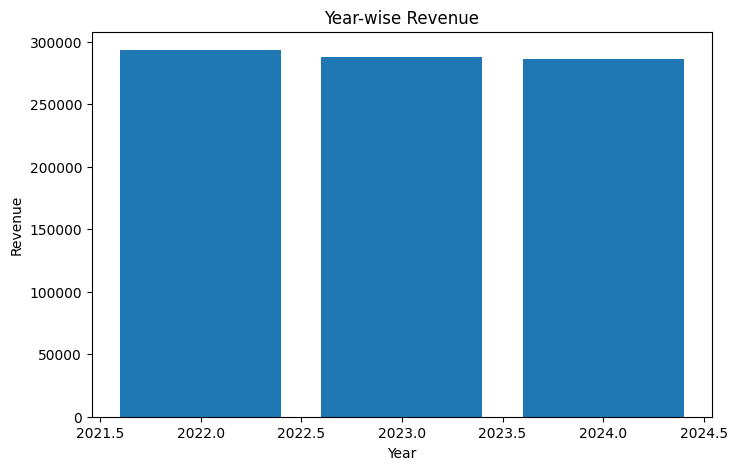

In [25]:
#Year-wise Revenue bar chart

plt.figure(figsize=(8, 5))

plt.bar(yearly_sales.index, yearly_sales.values)

plt.title("Year-wise Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

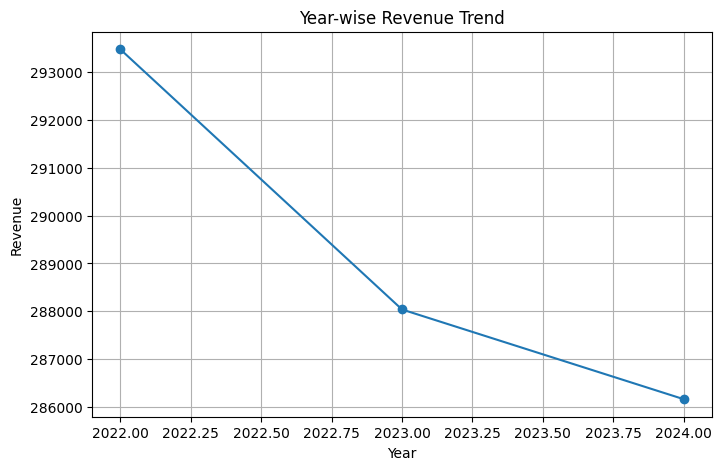

In [26]:
#Year-wise Revenue Trend

plt.figure(figsize=(8, 5))

plt.plot(yearly_sales.index, yearly_sales.values, marker="o")

plt.title("Year-wise Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.grid(True)
plt.show()

In [27]:
#Month-wise Revenue

monthly_sales = df.groupby("Month")["Revenue"].sum()

print(monthly_sales)

Month
1     73159.37
2     65046.36
3     76811.57
4     71878.67
5     74659.51
6     80757.81
7     76986.49
8     75040.17
9     63222.63
10    72951.64
11    66922.97
12    70236.82
Name: Revenue, dtype: float64


In [28]:
#Month-wise Units Sold

monthly_units = df.groupby("Month")["Units_Sold"].sum()

print(monthly_units)

Month
1     6001
2     5309
3     5985
4     5746
5     5888
6     6157
7     6149
8     6072
9     5134
10    5835
11    5166
12    5808
Name: Units_Sold, dtype: int64


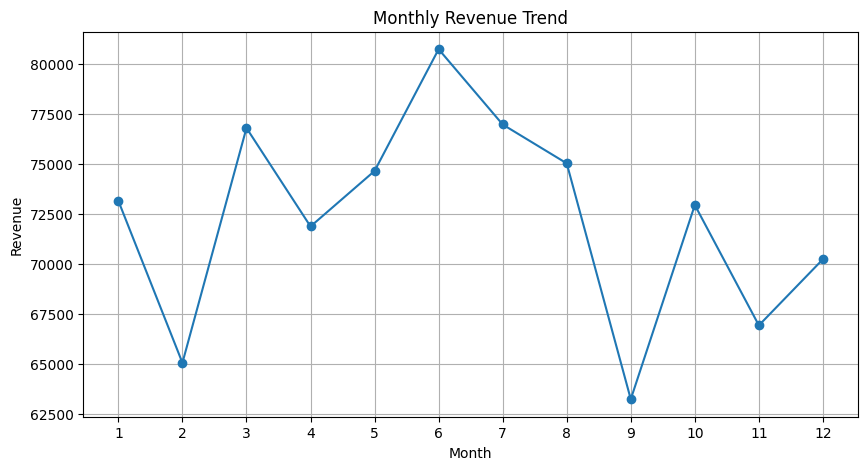

In [29]:
#Month-wise Revenue Chart

plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(range(1, 13))

plt.grid(True)
plt.show()

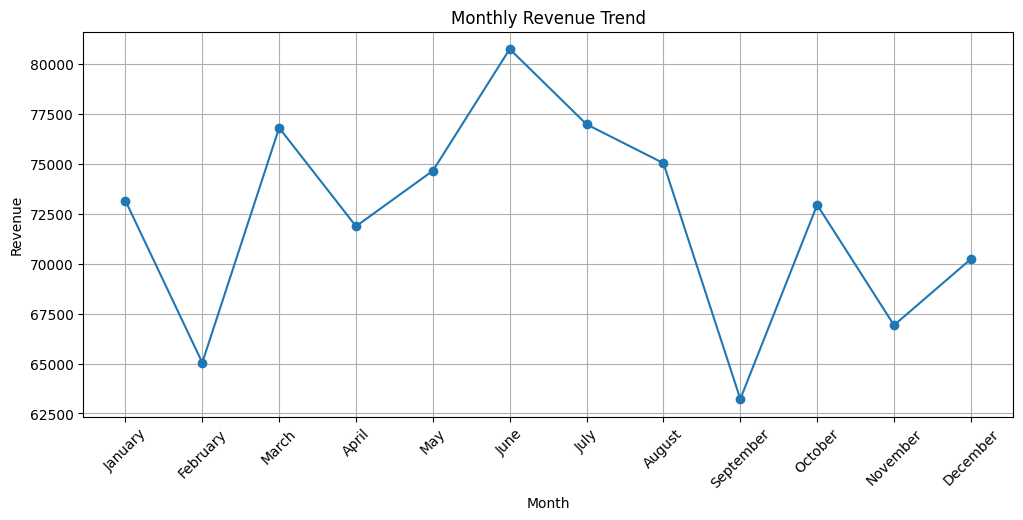

In [30]:
#Month names with chart



month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_sales_name = (
    df.groupby("Month_Name")["Revenue"]
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales_name.index,
    monthly_sales_name.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()


In [31]:
#Highest aur Lowest Revenue Month

highest_month = monthly_sales_name.idxmax()
highest_revenue = monthly_sales_name.max()

lowest_month = monthly_sales_name.idxmin()
lowest_revenue = monthly_sales_name.min()

print("Highest Revenue Month:", highest_month)
print("Highest Revenue:", round(highest_revenue, 2))

print("Lowest Revenue Month:", lowest_month)
print("Lowest Revenue:", round(lowest_revenue, 2))

Highest Revenue Month: June
Highest Revenue: 80757.81
Lowest Revenue Month: September
Lowest Revenue: 63222.63


In [32]:
#Product-wise Revenue

product_sales = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

print(product_sales)

Product
Pistachios    185471.20
Walnuts       184512.49
Cashews       171156.53
Raisins       163456.45
Almonds       163077.34
Name: Revenue, dtype: float64


In [33]:
#Product-wise Units Sold

product_units = df.groupby("Product")["Units_Sold"].sum().sort_values(ascending=False)

print(product_units)

Product
Pistachios    14699
Walnuts       14474
Cashews       13925
Almonds       13176
Raisins       12976
Name: Units_Sold, dtype: int64


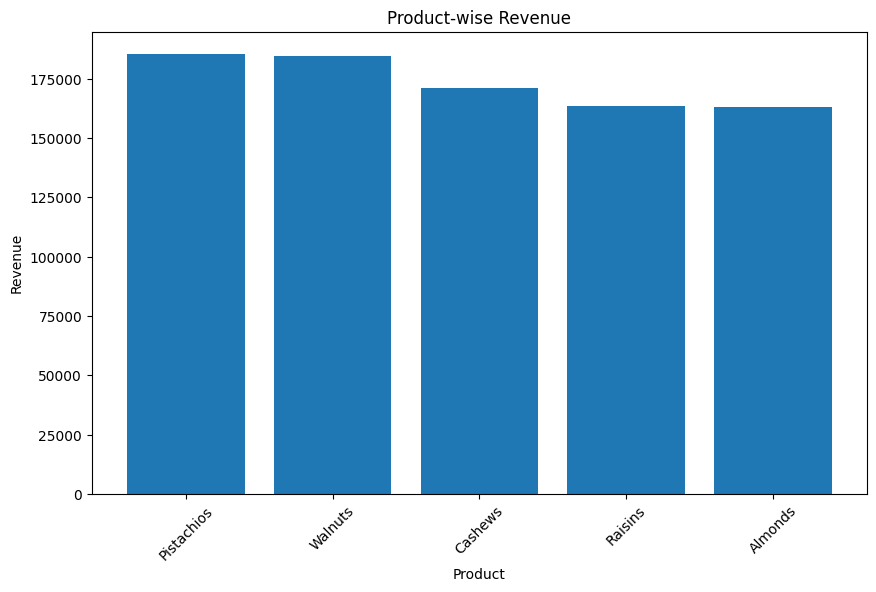

In [34]:
#Product Revenue Chart

plt.figure(figsize=(10, 6))

plt.bar(product_sales.index, product_sales.values)

plt.title("Product-wise Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [35]:
#Region-wise Revenue

region_sales = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

print(region_sales)

Region
East     224901.65
West     222707.49
North    210449.53
South    209615.34
Name: Revenue, dtype: float64


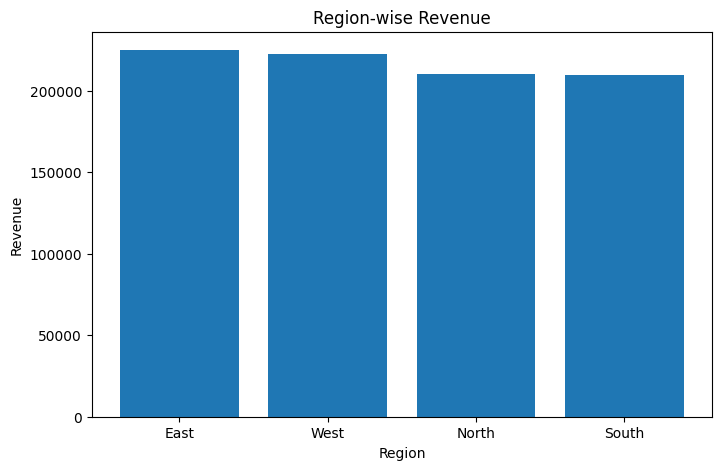

In [36]:
#Region Revenue Chart

plt.figure(figsize=(8, 5))

plt.bar(region_sales.index, region_sales.values)

plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.show()

In [37]:
#Region + Year Analysis 



region_year_sales = df.groupby(
    ["Year", "Region"]
)["Revenue"].sum().unstack()

print(region_year_sales)

Region      East     North     South      West
Year                                          
2022    76971.35  73632.18  66412.63  76455.50
2023    67152.47  75593.46  71654.33  73637.61
2024    80777.83  61223.89  71548.38  72614.38


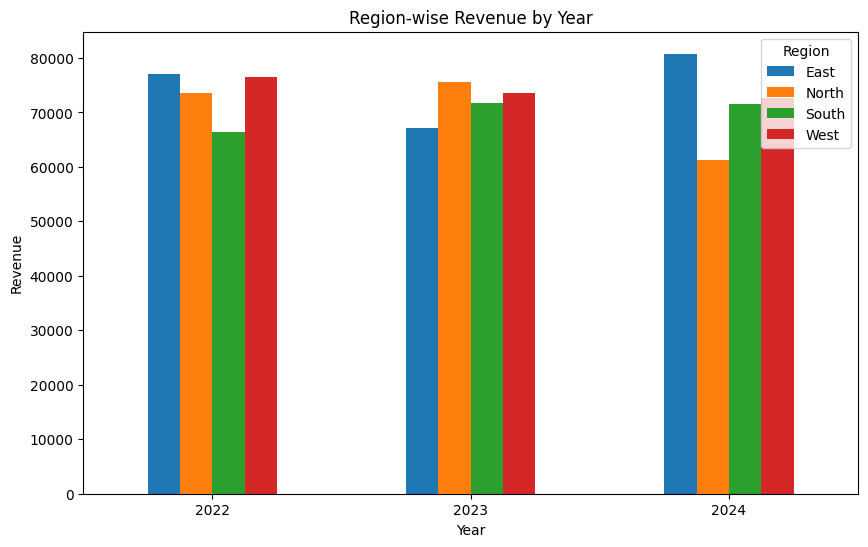

In [38]:
region_year_sales.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Region-wise Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

In [39]:
#Salesperson-wise Revenue

salesperson_revenue = (
    df.groupby("Salesperson")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(salesperson_revenue)

Salesperson
Ali      180548.77
Raj      178089.30
Anita    175866.58
Meena    175571.10
Sunil    157598.26
Name: Revenue, dtype: float64


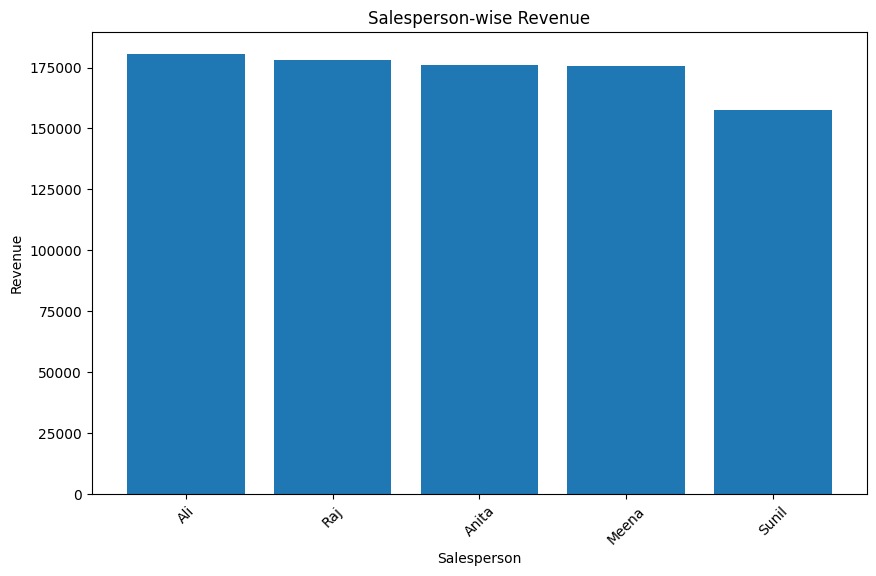

In [40]:
#Revenue Chart

plt.figure(figsize=(10, 6))

plt.bar(
    salesperson_revenue.index,
    salesperson_revenue.values
)

plt.title("Salesperson-wise Revenue")
plt.xlabel("Salesperson")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [41]:
#Top Salesperson

top_salesperson = salesperson_revenue.idxmax()
top_salesperson_revenue = salesperson_revenue.max()

print("Top Salesperson:", top_salesperson)
print("Revenue:", round(top_salesperson_revenue, 2))

Top Salesperson: Ali
Revenue: 180548.77


In [42]:
#Salesperson + Year Analysis

salesperson_year = df.groupby(
    ["Year", "Salesperson"]
)["Revenue"].sum().unstack()

print(salesperson_year)

Salesperson       Ali     Anita     Meena       Raj     Sunil
Year                                                         
2022         68676.96  53459.29  63513.27  56185.72  51636.42
2023         53563.31  57643.98  56729.10  66479.65  53621.83
2024         58308.50  64763.31  55328.73  55423.93  52340.01


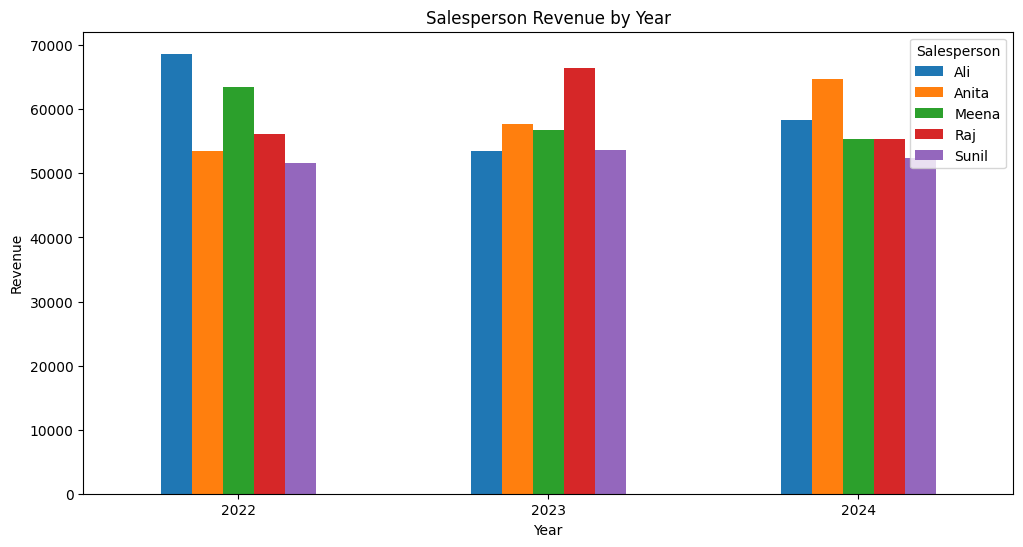

In [43]:
salesperson_year.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Salesperson Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

In [44]:
#Customer Type-wise Revenue

customer_revenue = (
    df.groupby("Customer_Type")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_revenue)

Customer_Type
Retail       436134.92
Wholesale    431539.09
Name: Revenue, dtype: float64


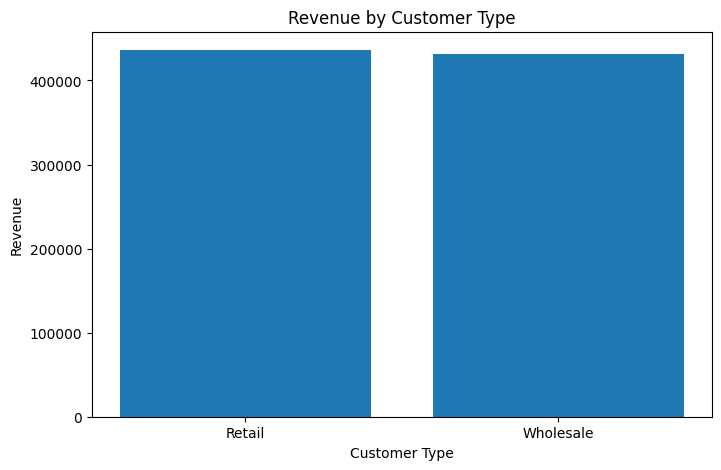

In [45]:
#Revenue Chart

plt.figure(figsize=(8, 5))

plt.bar(customer_revenue.index, customer_revenue.values)

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")

plt.show()

In [46]:
#Customer Type + Year Analysis 

customer_year = df.groupby(
    ["Year", "Customer_Type"]
)["Revenue"].sum().unstack()

print(customer_year)

Customer_Type     Retail  Wholesale
Year                               
2022           138526.25  154945.41
2023           150995.52  137042.35
2024           146613.15  139551.33


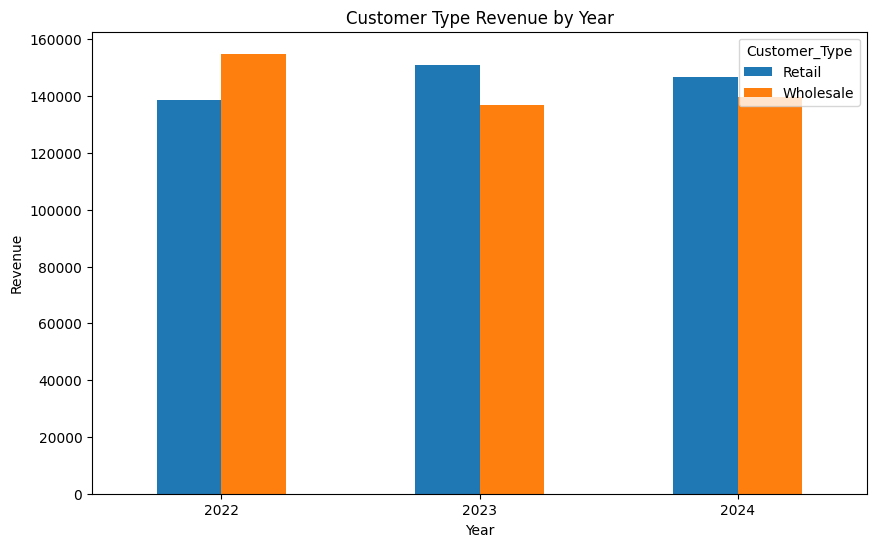

In [47]:
customer_year.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Type Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

In [48]:
#Best Customer Type

best_customer_type = customer_revenue.idxmax()
best_customer_revenue = customer_revenue.max()

print("Best Customer Type:", best_customer_type)
print("Revenue:", round(best_customer_revenue, 2))

Best Customer Type: Retail
Revenue: 436134.92


In [49]:
#Product + Region Revenue

product_region = df.groupby(
    ["Product", "Region"]
)["Revenue"].sum().sort_values(ascending=False)

print(product_region)

Product     Region
Pistachios  North     51390.53
Walnuts     East      51342.47
            West      49346.29
Cashews     South     47579.84
Pistachios  East      46507.74
Almonds     East      46145.76
Pistachios  South     44647.79
Cashews     West      44155.90
Almonds     West      43700.24
Pistachios  West      42925.14
Raisins     West      42579.92
Walnuts     South     42490.88
Cashews     East      41357.90
Walnuts     North     41332.85
Raisins     North     40847.27
            South     40481.48
            East      39547.78
Almonds     North     38815.99
Cashews     North     38062.89
Almonds     South     34415.35
Name: Revenue, dtype: float64


In [50]:
#Channel + Product Revenue

channel_product = pd.pivot_table(
    df,
    values="Revenue",
    index="Product",
    columns="Channel",
    aggfunc="sum"
)

print(channel_product)

Channel      Offline    Online
Product                       
Almonds     87133.31  75944.03
Cashews     83161.63  87994.90
Pistachios  94191.72  91279.48
Raisins     79657.89  83798.56
Walnuts     99612.73  84899.76


In [51]:
#Customer Type + Channel Revenue

customer_channel = pd.pivot_table(
    df,
    values="Revenue",
    index="Customer_Type",
    columns="Channel",
    aggfunc="sum"
)

print(customer_channel)

Channel          Offline     Online
Customer_Type                      
Retail         210930.53  225204.39
Wholesale      232826.75  198712.34


In [53]:
product_region_table = pd.pivot_table(
    df,
    values="Revenue",
    index="Product",
    columns="Region",
    aggfunc="sum"
)

print(product_region_table)

Region          East     North     South      West
Product                                           
Almonds     46145.76  38815.99  34415.35  43700.24
Cashews     41357.90  38062.89  47579.84  44155.90
Pistachios  46507.74  51390.53  44647.79  42925.14
Raisins     39547.78  40847.27  40481.48  42579.92
Walnuts     51342.47  41332.85  42490.88  49346.29


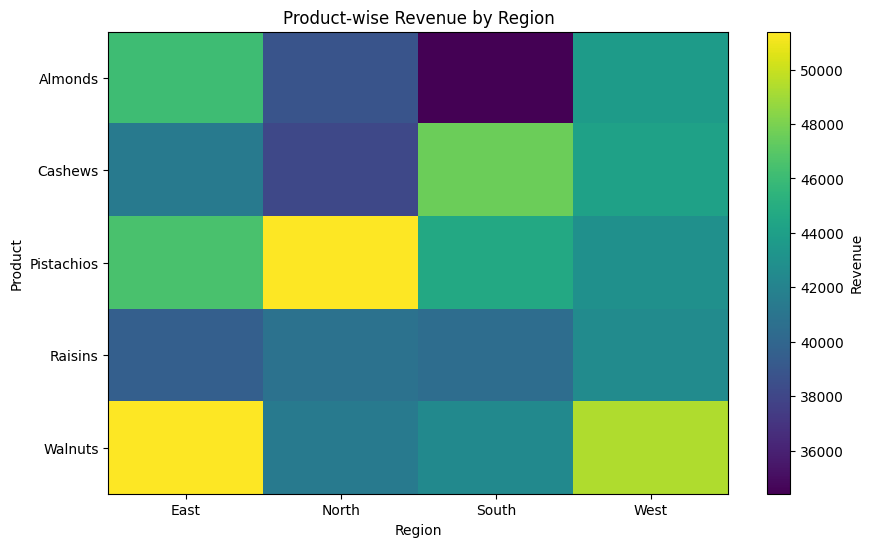

In [54]:
#Heatmap 



plt.figure(figsize=(10, 6))

plt.imshow(product_region_table, aspect="auto")

plt.colorbar(label="Revenue")

plt.xticks(
    range(len(product_region_table.columns)),
    product_region_table.columns
)

plt.yticks(
    range(len(product_region_table.index)),
    product_region_table.index
)

plt.title("Product-wise Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Product")

plt.show()

In [55]:
#Correlation calculate 

correlation = df["Units_Sold"].corr(df["Revenue"])

print("Correlation between Units Sold and Revenue:", round(correlation, 2))

Correlation between Units Sold and Revenue: 0.82


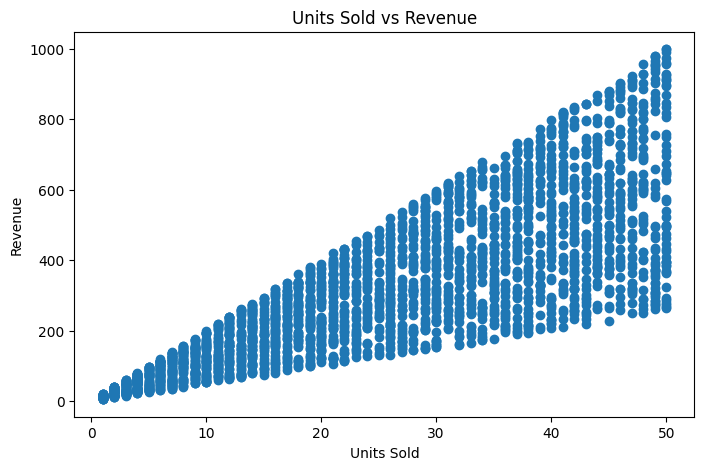

In [57]:
#Scatter Plot



plt.figure(figsize=(8, 5))

plt.scatter(df["Units_Sold"], df["Revenue"])

plt.title("Units Sold vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")

plt.show()

In [58]:
#Top 10 Revenue Records

top_10_sales = df.sort_values(
    by="Revenue",
    ascending=False
).head(10)

top_10_sales

,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type,Year,Month,Month_Name
757,2022-10-24,Pistachios,West,50,997.96,Ali,Offline,Wholesale,2022,10,October
627,2022-09-08,Cashews,North,50,997.58,Anita,Online,Retail,2022,9,September
182,2022-03-17,Raisins,East,50,989.70,Sunil,Online,Retail,2022,3,March
985,2023-01-27,Raisins,West,49,979.36,Ali,Offline,Wholesale,2023,1,January
1579,2023-09-16,Pistachios,South,49,977.62,Anita,Offline,Wholesale,2023,9,September
789,2022-11-08,Pistachios,South,49,976.73,Anita,Online,Wholesale,2022,11,November
1778,2023-12-12,Almonds,West,50,971.78,Meena,Offline,Wholesale,2023,12,December
2376,2024-08-09,Raisins,West,49,963.49,Anita,Offline,Wholesale,2024,8,August
2192,2024-05-29,Pistachios,North,50,958.70,Anita,Offline,Retail,2024,5,May
1431,2023-07-17,Almonds,West,49,956.34,Raj,Online,Retail,2023,7,July


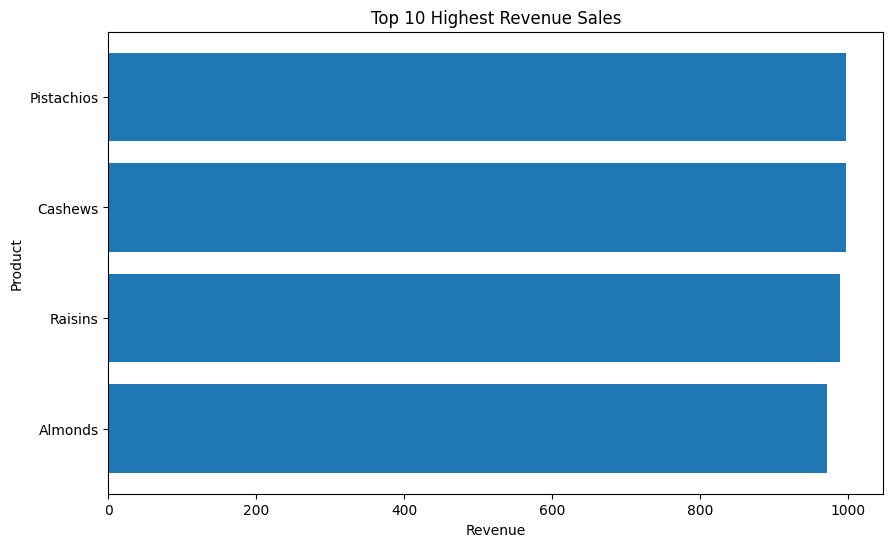

In [59]:
#Top 10 ka chart

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_sales["Product"],
    top_10_sales["Revenue"]
)

plt.title("Top 10 Highest Revenue Sales")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

In [60]:
#Salesperson + Product Revenue

salesperson_product = pd.pivot_table(
    df,
    values="Revenue",
    index="Salesperson",
    columns="Product",
    aggfunc="sum"
)

print(salesperson_product)

Product       Almonds   Cashews  Pistachios   Raisins   Walnuts
Salesperson                                                    
Ali          35752.85  39234.96    36654.38  37549.36  31357.22
Anita        30244.97  33204.17    37774.57  31489.21  43153.66
Meena        41681.03  33275.04    39344.53  26233.08  35037.42
Raj          29732.22  30845.04    40414.44  32650.00  44447.60
Sunil        25666.27  34597.32    31283.28  35534.80  30516.59


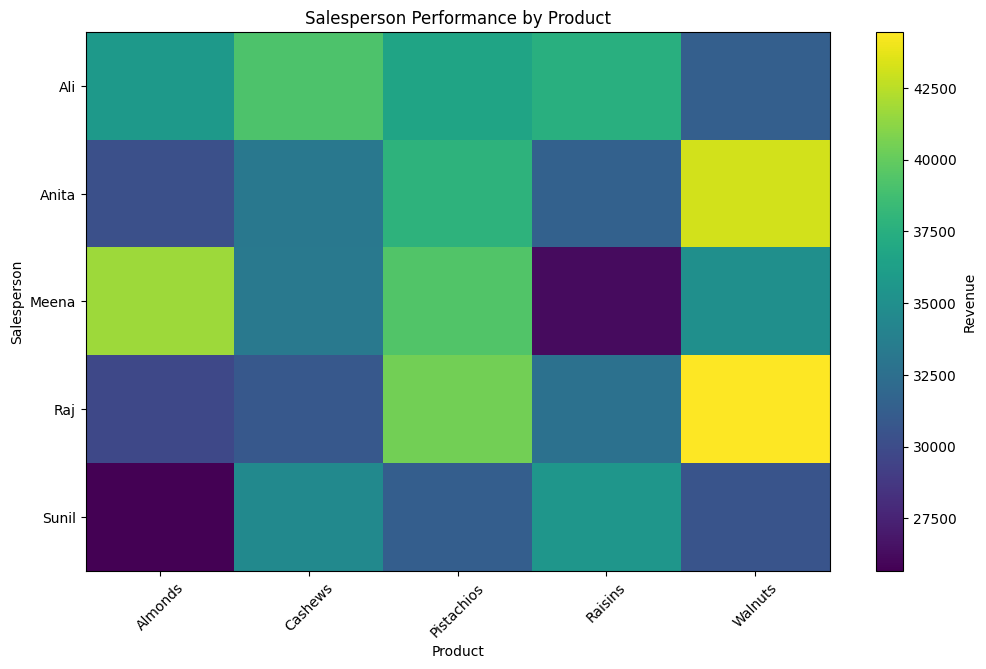

In [61]:
#Heatmap

plt.figure(figsize=(12, 7))

plt.imshow(salesperson_product, aspect="auto")

plt.colorbar(label="Revenue")

plt.xticks(
    range(len(salesperson_product.columns)),
    salesperson_product.columns,
    rotation=45
)

plt.yticks(
    range(len(salesperson_product.index)),
    salesperson_product.index
)

plt.title("Salesperson Performance by Product")
plt.xlabel("Product")
plt.ylabel("Salesperson")

plt.show()

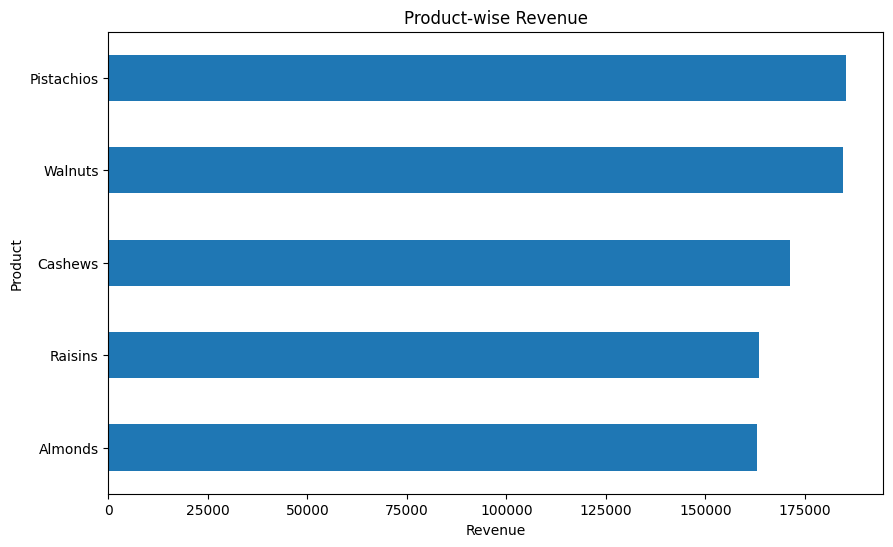

In [62]:
#Product-wise Revenue Chart

plt.figure(figsize=(10, 6))

product_sales.sort_values().plot(kind="barh")

plt.title("Product-wise Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

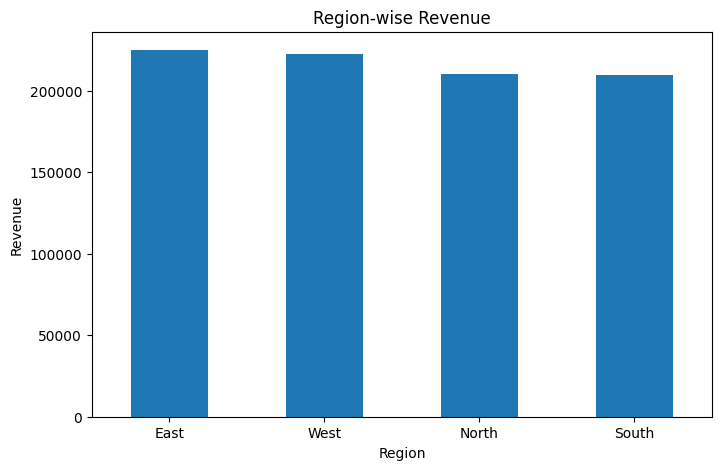

In [63]:
#Region-wise Revenue Chart

plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

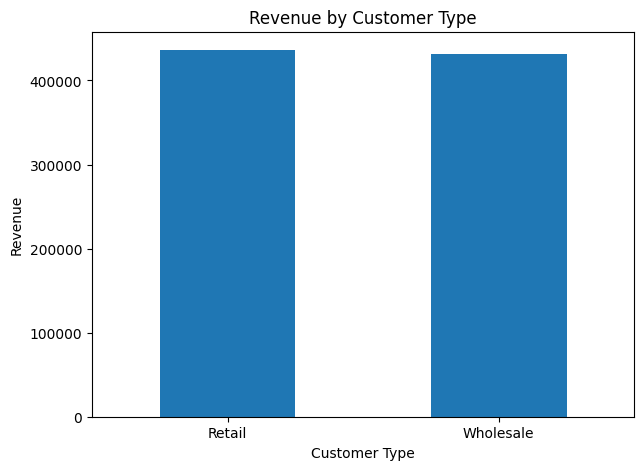

In [65]:
#Customer Type Chart

plt.figure(figsize=(7, 5))

customer_revenue.plot(kind="bar")

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()
plt.show()

In [ ]:
#Best Product

print("== BUSINESS INSIGHTS ==")

print("Best Product:", product_sales.idxmax())
print("Best Product Revenue:", round(product_sales.max(), 2))

===== BUSINESS INSIGHTS =====
Best Product: Pistachios
Best Product Revenue: 185471.2


In [67]:
#Best Region

print("Best Region:", region_sales.idxmax())
print("Best Region Revenue:", round(region_sales.max(), 2))

Best Region: East
Best Region Revenue: 224901.65


In [68]:
#Best Salesperson

print("Top Salesperson:", salesperson_revenue.idxmax())
print("Top Salesperson Revenue:", round(salesperson_revenue.max(), 2))

#Best Customer Type

print("Best Customer Type:", customer_revenue.idxmax())
print("Best Customer Revenue:", round(customer_revenue.max(), 2))

#Highest & Lowest Sales Month

print("Highest Sales Month:", monthly_sales_name.idxmax())
print("Highest Month Revenue:", round(monthly_sales_name.max(), 2))


print("Lowest Sales Month:", monthly_sales_name.idxmin())
print("Lowest Month Revenue:", round(monthly_sales_name.min(), 2))

Top Salesperson: Ali
Top Salesperson Revenue: 180548.77
Best Customer Type: Retail
Best Customer Revenue: 436134.92
Highest Sales Month: June
Highest Month Revenue: 80757.81
Lowest Sales Month: September
Lowest Month Revenue: 63222.63


In [ ]:
#Revenue basic statistical summary

revenue_stats = df["Revenue"].describe()

print(revenue_stats)

count    2738.000000
mean      316.900661
std       220.511950
min         5.180000
25%       138.652500
50%       274.415000
75%       450.852500
max       997.960000
Name: Revenue, dtype: float64


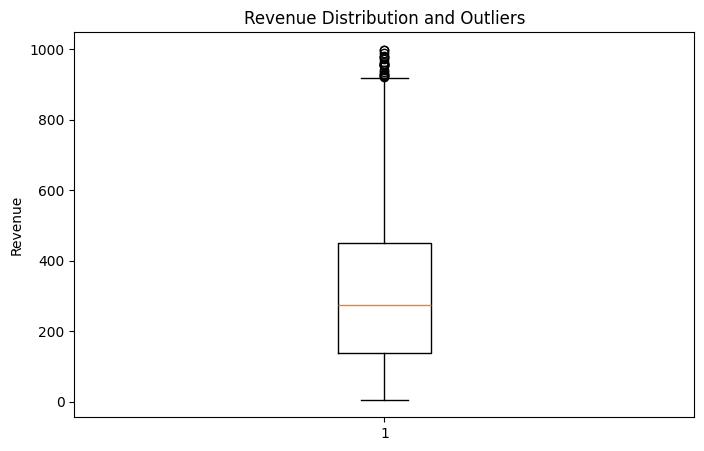

In [70]:
#Revenue Boxplot

plt.figure(figsize=(8, 5))

plt.boxplot(df["Revenue"])

plt.title("Revenue Distribution and Outliers")
plt.ylabel("Revenue")

plt.show()

In [71]:
#IQR method with exact outliers calculate 

Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 138.6525
Q3: 450.8525
IQR: 312.20000000000005
Lower Limit: -329.64750000000004
Upper Limit: 919.1525000000001


In [72]:
#Outliers identify 

outliers = df[
    (df["Revenue"] < lower_limit) |
    (df["Revenue"] > upper_limit)
]

print("Number of Revenue Outliers:", len(outliers))

Number of Revenue Outliers: 21


In [73]:
#Outlier records dekho

outliers[
    [
        "Date",
        "Product",
        "Region",
        "Units_Sold",
        "Revenue",
        "Salesperson",
        "Channel",
        "Customer_Type"
    ]
].head(10)

,Date,Product,Region,Units_Sold,Revenue,Salesperson,Channel,Customer_Type
114,2022-02-13,Raisins,East,49,953.76,Sunil,Online,Retail
172,2022-03-11,Walnuts,East,48,927.76,Ali,Offline,Wholesale
182,2022-03-17,Raisins,East,50,989.70,Sunil,Online,Retail
586,2022-08-22,Almonds,West,48,956.19,Anita,Offline,Wholesale
627,2022-09-08,Cashews,North,50,997.58,Anita,Online,Retail
757,2022-10-24,Pistachios,West,50,997.96,Ali,Offline,Wholesale
789,2022-11-08,Pistachios,South,49,976.73,Anita,Online,Wholesale
867,2022-12-14,Cashews,North,50,956.26,Sunil,Offline,Retail
985,2023-01-27,Raisins,West,49,979.36,Ali,Offline,Wholesale
1050,2023-02-21,Raisins,North,48,927.97,Meena,Offline,Retail


In [74]:
print("========== FINAL EDA BUSINESS INSIGHTS ==========\n")

print("1. Overall Performance")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Units Sold: {total_units:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Revenue per Transaction: {average_revenue:,.2f}")

print("\n2. Product Performance")
print(f"Best Product: {product_sales.idxmax()}")
print(f"Best Product Revenue: {product_sales.max():,.2f}")

print("\n3. Regional Performance")
print(f"Best Region: {region_sales.idxmax()}")
print(f"Best Region Revenue: {region_sales.max():,.2f}")

print("\n4. Salesperson Performance")
print(f"Top Salesperson: {salesperson_revenue.idxmax()}")
print(f"Top Salesperson Revenue: {salesperson_revenue.max():,.2f}")

print("\n5. Customer Performance")
print(f"Top Customer Type: {customer_revenue.idxmax()}")
print(f"Top Customer Revenue: {customer_revenue.max():,.2f}")

print("\n6. Monthly Performance")
print(f"Highest Revenue Month: {monthly_sales_name.idxmax()}")
print(f"Highest Month Revenue: {monthly_sales_name.max():,.2f}")

print(f"Lowest Revenue Month: {monthly_sales_name.idxmin()}")
print(f"Lowest Month Revenue: {monthly_sales_name.min():,.2f}")

print("\n7. Correlation")
print(f"Units Sold vs Revenue Correlation: {df['Units_Sold'].corr(df['Revenue']):.2f}")

========== FINAL EDA BUSINESS INSIGHTS ==========

1. Overall Performance
Total Revenue: 867,674.01
Total Units Sold: 69,250
Total Transactions: 2,738
Average Revenue per Transaction: 316.90

2. Product Performance
Best Product: Pistachios
Best Product Revenue: 185,471.20

3. Regional Performance
Best Region: East
Best Region Revenue: 224,901.65

4. Salesperson Performance
Top Salesperson: Ali
Top Salesperson Revenue: 180,548.77

5. Customer Performance
Top Customer Type: Retail
Top Customer Revenue: 436,134.92

6. Monthly Performance
Highest Revenue Month: June
Highest Month Revenue: 80,757.81
Lowest Revenue Month: September
Lowest Month Revenue: 63,222.63

7. Correlation
Units Sold vs Revenue Correlation: 0.82


In [77]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[["Units_Sold"]]
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (2190, 1)
Testing Data: (548, 1)


In [78]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [79]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 12.305032344351465
Intercept: 4.0170275678808025


In [80]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[471.60825665 496.21832134  65.54218929 410.08309493 262.4227068
 225.50760977 397.77806259  28.62709226 188.59251273 323.94786852]


In [81]:
comparison = pd.DataFrame({
    "Actual Revenue": y_test.values,
    "Predicted Revenue": y_pred
})

comparison.head(10)

,Actual Revenue,Predicted Revenue
0,226.59,471.608257
1,294.66,496.218321
2,47.59,65.542189
3,534.47,410.083095
4,306.69,262.422707
5,304.89,225.507610
6,539.44,397.778063
7,26.77,28.627092
8,188.74,188.592513
9,146.22,323.947869


In [82]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("========== MODEL PERFORMANCE ==========")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

========== MODEL PERFORMANCE ==========
MAE : 99.28
MSE : 17471.52
RMSE: 132.18
R² Score: 0.66


In [83]:
print("========== FINAL BUSINESS RECOMMENDATIONS ==========\n")

print("1. Product Recommendation")
print(f"{product_sales.idxmax()} is the highest revenue-generating product.")
print("The company should maintain its availability and consider increasing its promotion.")

print("\n2. Region Recommendation")
print(f"{region_sales.idxmax()} is the best-performing region.")
print("The company can use this region as a benchmark and focus on improving weaker regions.")

print("\n3. Salesperson Recommendation")
print(f"{salesperson_revenue.idxmax()} is the top-performing salesperson.")
print("The company can study the working strategy of top performers and share best practices.")

print("\n4. Customer Recommendation")
print(f"{customer_revenue.idxmax()} contributes the highest revenue.")
print("The company should focus on retaining this customer segment and increasing repeat business.")

print("\n5. Overall Recommendation")
print("The company should focus on high-performing products, regions, salespeople,")
print("channels and customer segments while improving weaker-performing areas.")

========== FINAL BUSINESS RECOMMENDATIONS ==========

1. Product Recommendation
Pistachios is the highest revenue-generating product.
The company should maintain its availability and consider increasing its promotion.

2. Region Recommendation
East is the best-performing region.
The company can use this region as a benchmark and focus on improving weaker regions.

3. Salesperson Recommendation
Ali is the top-performing salesperson.
The company can study the working strategy of top performers and share best practices.

4. Customer Recommendation
Retail contributes the highest revenue.
The company should focus on retaining this customer segment and increasing repeat business.

5. Overall Recommendation
The company should focus on high-performing products, regions, salespeople,
channels and customer segments while improving weaker-performing areas.
